# Predicting Student Academic Outcomes: A Classical ML vs Neural Network Study
**Author:** Divine Ebube Ifechukwude  
**Dataset:** Predict Students' Dropout and Academic Success — UCI #697  
**Date:** May 2026

In [1]:
!pip install ucimlrepo scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## 1. Introduction

### 1.1 Background and Motivation

Student dropout is one of the most costly problems in higher education. When a student leaves before completing their degree, it represents a failure for the student, the institution, and in many cases the wider community that funded their education. Early prediction systems that identify at-risk students before they reach the point of dropout give institutions a window to intervene with targeted support.

This study builds and compares two approaches to that prediction problem: classical machine learning models trained using scikit-learn, and a three-layer neural network implemented entirely from scratch in NumPy. The goal is not just to build working models, but to understand what each approach does, why it works, and where it falls short.

### 1.2 Dataset Overview

The dataset used is the Predict Students' Dropout and Academic Success dataset from the UCI Machine Learning Repository (ID 697), created by Martins et al. (2021). It was collected from a Portuguese higher education institution and covers student records from multiple undergraduate degrees. Each record includes 36 features covering the student's demographic background, socioeconomic situation, prior academic performance, and results from the first and second semesters of study. The target variable has three classes: Dropout, Enrolled, and Graduate.

The dataset was chosen because it addresses a genuine real-world problem, contains no missing values, has a meaningful class structure for multi-class classification, and comes with a published paper that can be cited directly (Martins et al., 2021).

### 1.3 Study Objectives

This notebook has four objectives. First, to explore and understand the dataset before making any modelling decisions. Second, to train and evaluate at least two classical classifiers with deliberate hyperparameter experimentation. Third, to implement a neural network from scratch in NumPy, including forward propagation, backpropagation, and a training loop. Fourth, to compare both approaches honestly and explain the differences in performance.

Martins, M. V., Tolledo, D., Machado, J., Baptista, L. M. T., & Realinho, V. (2021). Early prediction of student's performance in higher education: A case study. In Trends and Applications in Information Systems and Technologies (pp. 166-175). Springer.

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

## 2. Exploratory Data Analysis

### 2.1 Dataset Loading

The dataset is fetched directly from the UCI ML Repository using the ucimlrepo library. It contains 4,424 student records and 36 features, with no missing values. The target column holds string labels that will be encoded to integers in the preprocessing step.

Martins, M. V., Tolledo, D., Machado, J., Baptista, L. M. T., & Realinho, V. (2021). Early prediction of student's performance in higher education: A case study. In Trends and Applications in Information Systems and Technologies (pp. 166-175). Springer.

In [3]:
dataset = fetch_ucirepo(id=697)

X = dataset.data.features
y = dataset.data.targets

df = X.copy()
df['Target'] = y.values.ravel()

print('Dataset shape:', df.shape)
print()
print('Target value counts:')
print(df['Target'].value_counts())
print()
print('Dtypes summary:')
print(df.dtypes.value_counts())

Dataset shape: (4424, 37)

Target value counts:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Dtypes summary:
int64      29
float64     7
str         1
Name: count, dtype: int64


### 2.2 Class Distribution

The three outcome classes are not equally represented. Graduate makes up 49.9% of the dataset, Dropout 32.1%, and Enrolled just 17.9%. This matters because a model that predicts Graduate for every single student would still achieve roughly 50% accuracy without learning anything useful. That is the majority class baseline, and every model built in this study has to beat it to be considered meaningful.

The deeper issue is how gradient descent responds to this imbalance. During training, the model updates its parameters to minimise the loss. Because Graduate appears in nearly half of all samples, predicting it more often reduces the loss more reliably than trying to distinguish between all three classes. The model is not making a deliberate choice. It is simply following the path that reduces the loss fastest given the data distribution.

For this reason, accuracy alone will not be the main evaluation metric. Weighted F1-score will be used instead, since it accounts for class size differences when averaging precision and recall. The Enrolled class at 17.9% is expected to be the hardest to predict and will be watched closely across all experiments. Class weights will also be applied during training to penalise minority-class errors more heavily (King & Zeng, 2001).

King, G., & Zeng, L. (2001). Logistic regression in rare events data. Political Analysis, 9(2), 137-163.

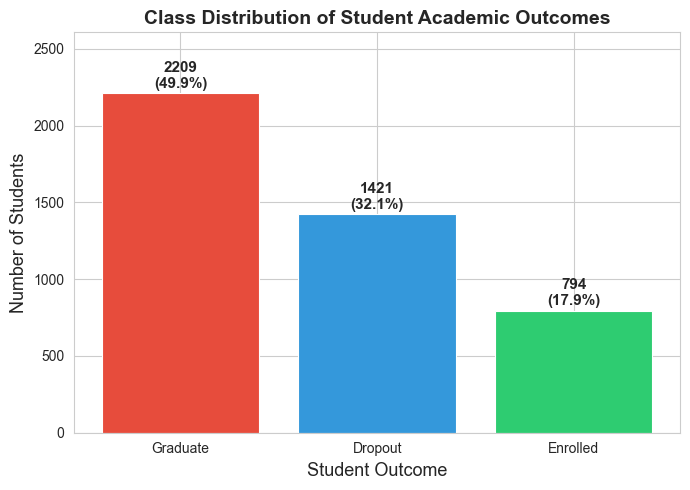

In [4]:
class_counts = df['Target'].value_counts()
class_pcts = df['Target'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(class_counts.index, class_counts.values,
              color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='white', linewidth=0.8)

for bar, count, pct in zip(bars, class_counts.values, class_pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 15,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Student Outcome', fontsize=13)
ax.set_ylabel('Number of Students', fontsize=13)
ax.set_title('Class Distribution of Student Academic Outcomes', fontsize=14, fontweight='bold')
ax.set_ylim(0, class_counts.max() * 1.18)
plt.tight_layout()
plt.show()

### 2.3 Feature Statistics

Before building any model, it helps to look at the raw numerical properties of each feature. The main thing to check here is range, which is the difference between the maximum and minimum value of a feature. Range matters because models that rely on distances or gradient updates are sensitive to the scale of input values.

A feature with a large range will dominate distance calculations and produce much larger gradient updates than a feature with a small range, regardless of whether it is actually more informative. This is a numerical artefact, not a reflection of predictive value (Bishop, 2006).

The results show that Course has the largest range at 9,958. This is particularly misleading because Course is a categorical identifier encoded as an integer. The numerical gap between two course codes means nothing, yet an unscaled model would treat it as if it does. The smallest range belongs to Daytime/evening attendance at 1.0, a simple binary indicator. This gap between features confirms that standardisation is needed before any model sees the data.

Bishop, C. M. (2006). Pattern Recognition and Machine Learning. Springer.
Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning (2nd ed.). Springer.

In [5]:
desc = df.drop(columns='Target').describe().T
desc['range'] = desc['max'] - desc['min']

print('Descriptive statistics (transposed):')
display(desc)

largest_range_feat = desc['range'].idxmax()
smallest_range_feat = desc['range'].idxmin()

print(f"\nFeature with LARGEST range : '{largest_range_feat}' "
      f"(range = {desc.loc[largest_range_feat, 'range']:.2f})")
print(f"Feature with SMALLEST range: '{smallest_range_feat}' "
      f"(range = {desc.loc[smallest_range_feat, 'range']:.4f})")

Descriptive statistics (transposed):


,count,mean,std,min,25%,50%,75%,max,range
Marital Status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000,5.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000,56.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000,9958.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000,42.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000,95.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000,108.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000,43.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000,43.000000



Feature with LARGEST range : 'Course' (range = 9958.00)
Feature with SMALLEST range: 'Daytime/evening attendance' (range = 1.0000)


### 2.4 Correlation Analysis

The correlation heatmap shows the pairwise linear relationships between all features and the target variable. Two things are worth looking for. First, which features are most strongly correlated with the target, since these are likely to carry the most predictive signal. Second, whether any features are highly correlated with each other, since that kind of multicollinearity can create problems for linear models like Logistic Regression.

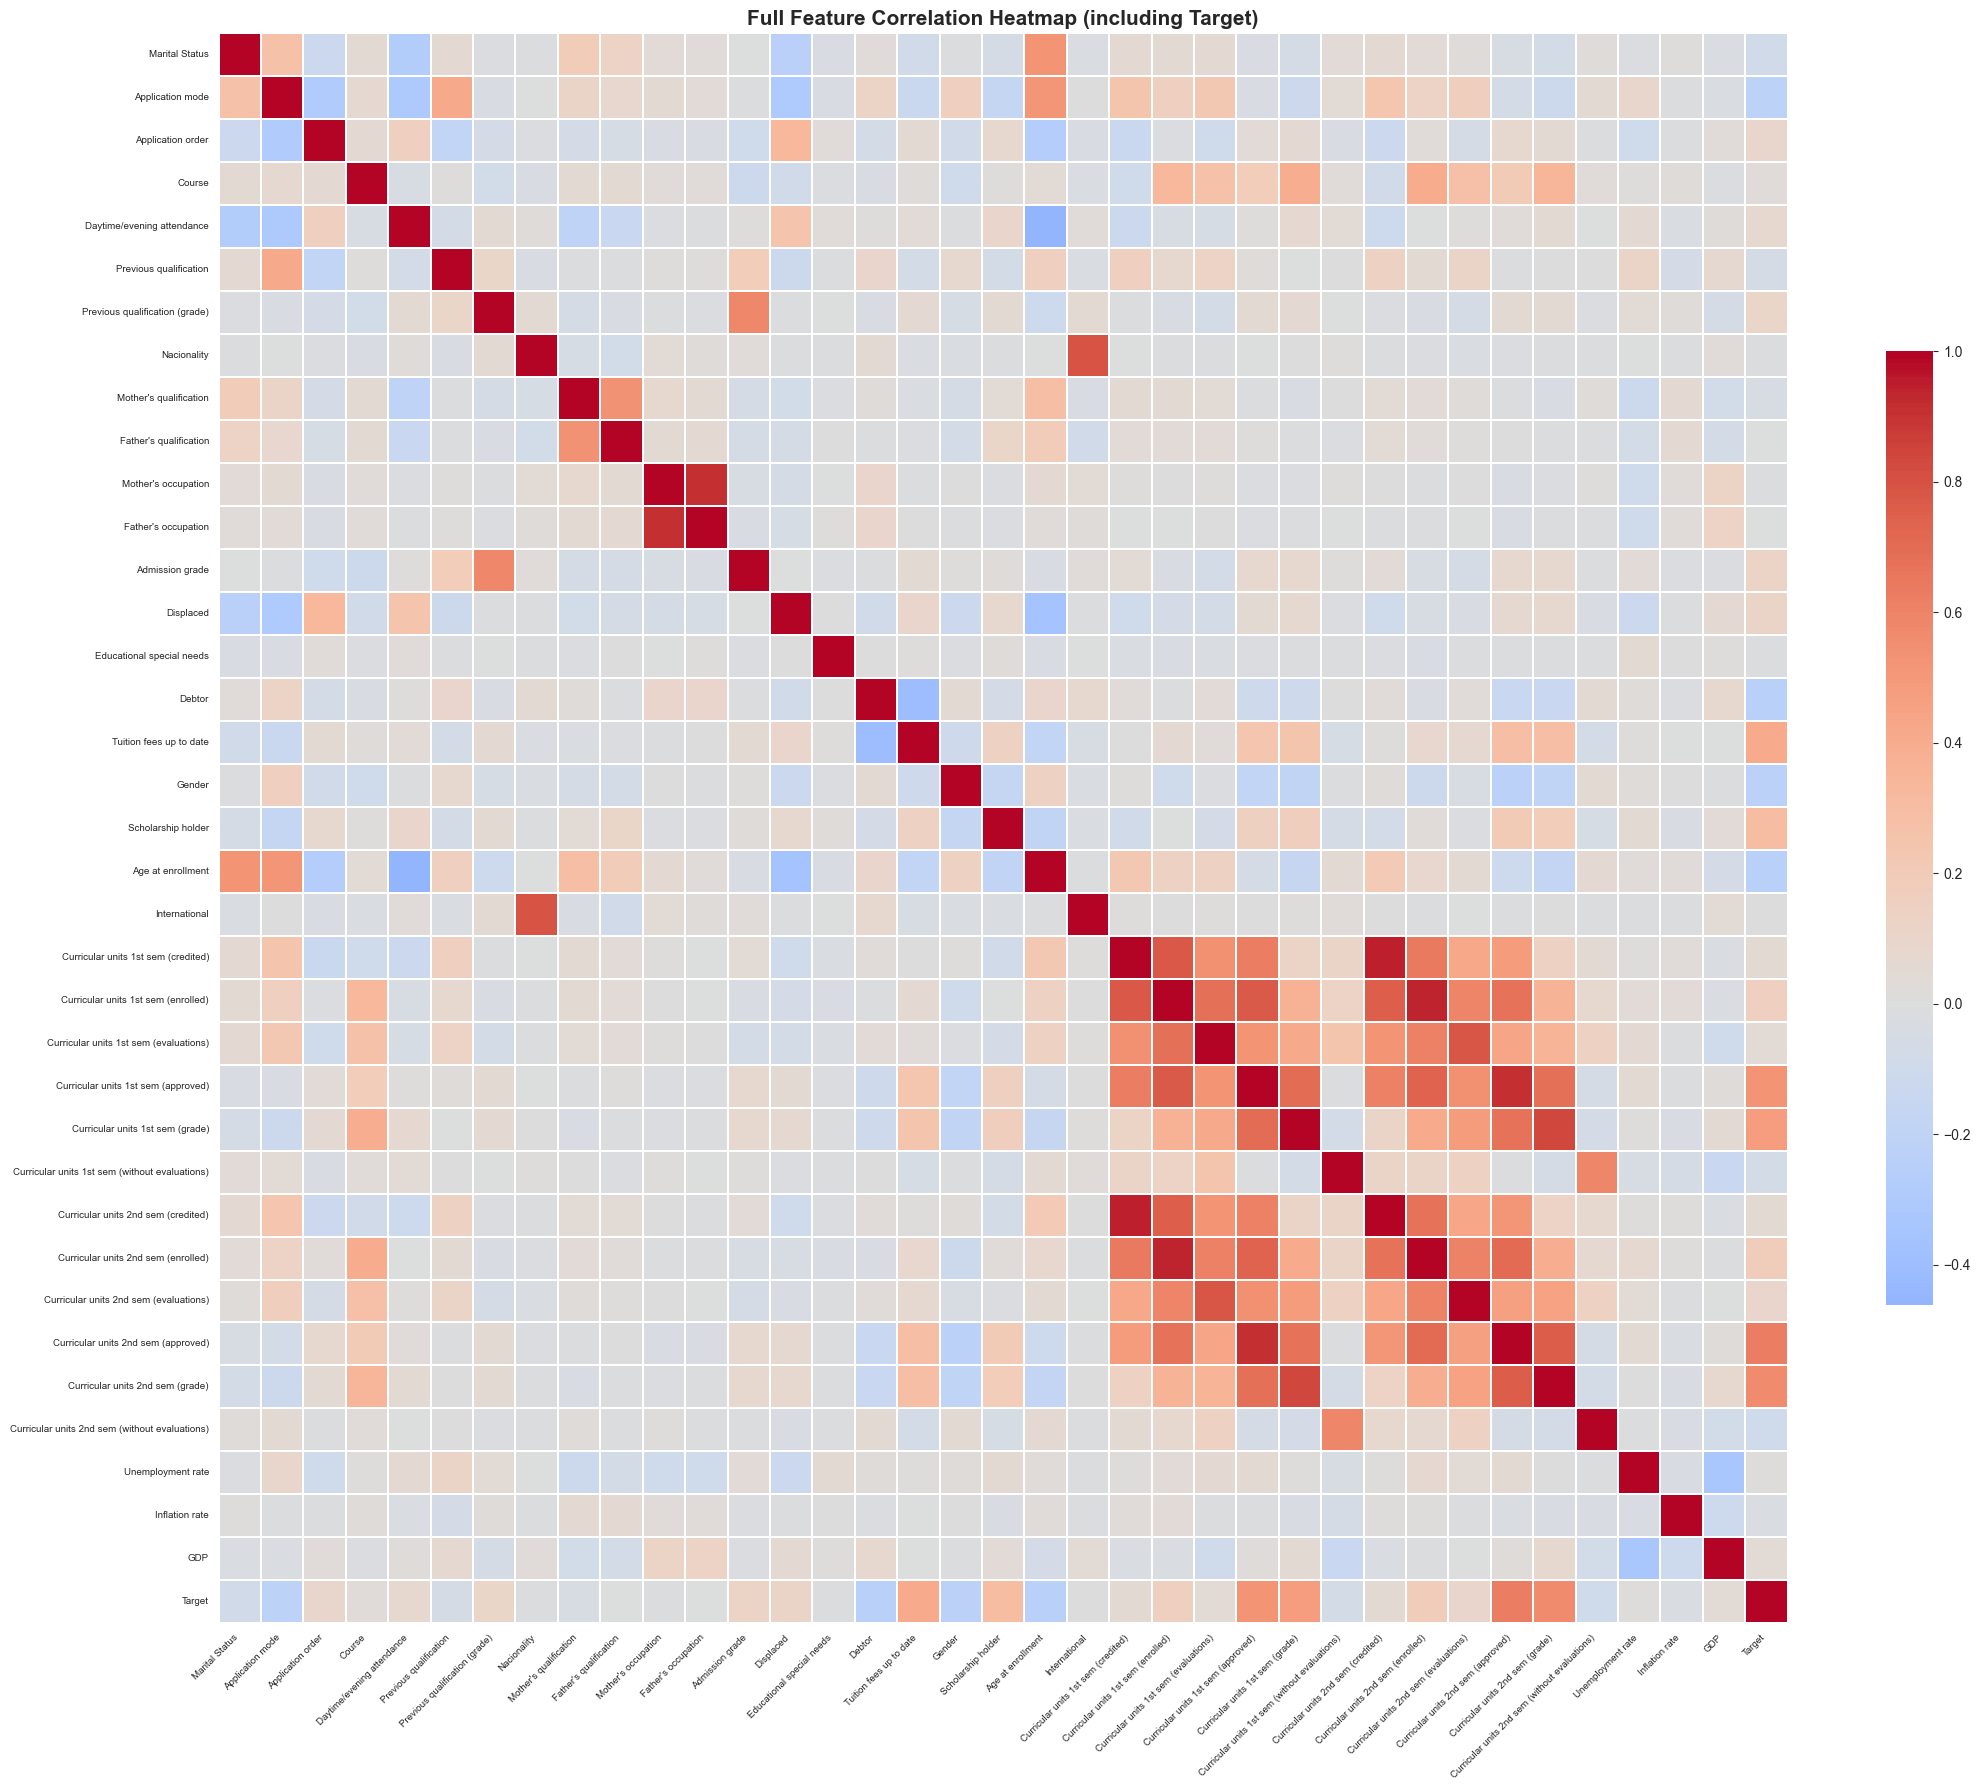

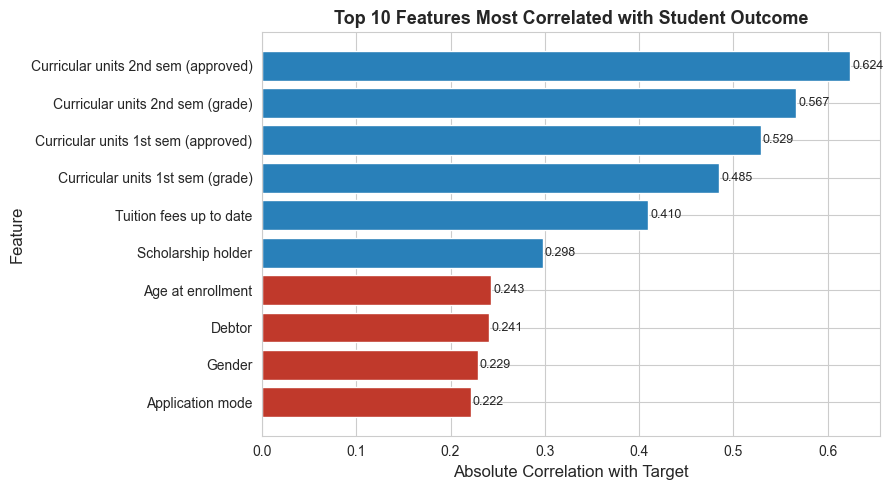

In [6]:
label_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df_corr = df.copy()
df_corr['Target'] = df_corr['Target'].map(label_map)

corr_matrix = df_corr.corr()

# --- Full heatmap ---
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'shrink': 0.6}
)
ax.set_title('Full Feature Correlation Heatmap (including Target)', fontsize=15, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

# --- Top 10 features correlated with Target ---
target_corr = corr_matrix['Target'].drop('Target').abs().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2980b9' if corr_matrix['Target'].loc[f] >= 0 else '#c0392b' for f in target_corr.index]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Absolute Correlation with Target', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Top 10 Features Most Correlated with Student Outcome', fontsize=13, fontweight='bold')
for i, (val, feat) in enumerate(zip(target_corr.values[::-1], target_corr.index[::-1])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 2.5 EDA Findings and Implications

The EDA produced four findings that directly shape the decisions made in every section that follows.

The strongest predictors of student outcome are all academic performance features. Curricular units approved and grades from both semesters have absolute correlations with the target of 0.624, 0.567, 0.529, and 0.485. This makes intuitive sense. A student failing their modules in semester one is already showing the clearest measurable sign of being at risk. Features below 0.3 correlation, such as Age, Debtor status, and Gender, carry weaker individual signal but are kept in the dataset because ensemble models like Random Forest can still extract value from them through feature interactions (Breiman, 2001).

The curricular unit features are also highly correlated with each other, as visible in the dense red cluster in the heatmap. Semester one performance correlates strongly with semester two performance. This is multicollinearity, and it poses a direct threat to Logistic Regression because correlated features inflate coefficient variance and make parameter estimates unstable (Bishop, 2006). This is one reason why L2 regularisation will be applied to all Logistic Regression experiments, and why Random Forest is included as the second model, since it handles multicollinearity naturally through random feature subsampling at each split.

Feature scales vary enormously, from Course at 9,958 to Daytime/evening attendance at 1.0. All features will be standardised using the z-score formula before training. The parameters for this transformation will be computed from training data only to avoid data leakage.

The class distribution is imbalanced. Graduate accounts for 49.9%, Dropout for 32.1%, and Enrolled for only 17.9%. Weighted F1-score will be the primary evaluation metric, and class weights will be applied during training to correct for this imbalance.

Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5-32.
Bishop, C. M. (2006). Pattern Recognition and Machine Learning. Springer.
Tinto, V. (1975). Dropout from higher education: A theoretical synthesis of recent research. Review of Educational Research, 45(1), 89-125.

## 3. Data Preprocessing

Preprocessing turns the raw dataset into something models can actually work with. Three findings from the EDA drive the decisions here. The extreme scale differences between features mean standardisation is needed. The class imbalance means training needs to be corrected with class weights. And the string target labels need to be converted to integers before any maths can happen. All transformations are done manually in NumPy so the arithmetic is visible and traceable (Hastie et al., 2009).

Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning (2nd ed.). Springer.

### 3.1 Label Encoding

The target column contains strings: Dropout, Enrolled, and Graduate. These need to be mapped to integers before they can be used in any calculation. The mapping used is Dropout to 0, Enrolled to 1, and Graduate to 2. This roughly follows the natural arc of a student's journey through a degree, which makes it easy to read, but it does not imply any ordering that the model will use. The classes are treated as nominal throughout.

For the neural network specifically, these integers will be converted further into one-hot vectors. Graduate, for example, becomes [0, 0, 1]. This is required because the output layer uses Softmax, which produces a three-dimensional probability vector, and that cannot be compared to a single integer using cross-entropy loss.

In [7]:
LABEL_MAP   = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
LABEL_NAMES = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}

y_encoded = df['Target'].map(LABEL_MAP).to_numpy()

# Verify first 10 labels side-by-side
print('First 10 encoded labels vs original strings:')
print(f'{"Original":<12} {"Encoded"}')
print('-' * 22)
for orig, enc in zip(df['Target'].values[:10], y_encoded[:10]):
    print(f'{orig:<12} {enc}')

print()
print('Class distribution after encoding (should match EDA counts):')
unique, counts = np.unique(y_encoded, return_counts=True)
total = len(y_encoded)
print(f'{"Class":<10} {"Label":<12} {"Count":>6} {"Pct":>7}')
print('-' * 38)
for u, c in zip(unique, counts):
    print(f'{u:<10} {LABEL_NAMES[u]:<12} {c:>6} {c/total*100:>6.1f}%')

First 10 encoded labels vs original strings:
Original     Encoded
----------------------
Dropout      0
Graduate     2
Dropout      0
Graduate     2
Graduate     2
Graduate     2
Graduate     2
Dropout      0
Graduate     2
Dropout      0

Class distribution after encoding (should match EDA counts):
Class      Label         Count     Pct
--------------------------------------
0          Dropout        1421   32.1%
1          Enrolled        794   17.9%
2          Graduate       2209   49.9%


### 3.2 Train/Test Split

The data is split into 80% training and 20% test. With 4,424 total samples, this gives roughly 3,539 training examples and 885 test examples. The training set is large enough for both classical models and the neural network to learn from. The test set is large enough to give stable per-class metric estimates.

Stratification is applied to preserve the original class proportions in both splits. Without it, a random split could place very few Enrolled examples in the test set, which would make the per-class metrics for that class unreliable. sklearn's train_test_split handles the stratified sampling here. This is the only sklearn call used in the preprocessing section.

In [8]:
from sklearn.model_selection import train_test_split

X_raw = df.drop(columns='Target').values
y     = y_encoded

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print('Split shapes:')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')

print()
print('Class distribution — training set:')
u_tr, c_tr = np.unique(y_train, return_counts=True)
print(f'{"Class":<10} {"Label":<12} {"Count":>6} {"Pct":>7}')
print('-' * 38)
for u, c in zip(u_tr, c_tr):
    print(f'{u:<10} {LABEL_NAMES[u]:<12} {c:>6} {c/len(y_train)*100:>6.1f}%')

print()
print('Class distribution — test set:')
u_te, c_te = np.unique(y_test, return_counts=True)
print(f'{"Class":<10} {"Label":<12} {"Count":>6} {"Pct":>7}')
print('-' * 38)
for u, c in zip(u_te, c_te):
    print(f'{u:<10} {LABEL_NAMES[u]:<12} {c:>6} {c/len(y_test)*100:>6.1f}%')

Split shapes:
  X_train : (3539, 36)
  X_test  : (885, 36)
  y_train : (3539,)
  y_test  : (885,)

Class distribution — training set:
Class      Label         Count     Pct
--------------------------------------
0          Dropout        1137   32.1%
1          Enrolled        635   17.9%
2          Graduate       1767   49.9%

Class distribution — test set:
Class      Label         Count     Pct
--------------------------------------
0          Dropout         284   32.1%
1          Enrolled        159   18.0%
2          Graduate        442   49.9%


### 3.3 Manual Standardisation

Each feature is scaled using the z-score formula:

$$z = \frac{x - \mu}{\sigma}$$

Here $x$ is the original feature value, $\mu$ is the mean of that feature computed from the training data, and $\sigma$ is the standard deviation computed from the training data. After this transformation, every feature in the training set has mean zero and standard deviation one, so no single feature dominates the others because of its original scale.

The key constraint is that $\mu$ and $\sigma$ are computed from training data only, then applied to the test set using those same values. If they were computed on the full dataset, the model would have indirectly seen test set statistics during preprocessing. That is data leakage, and it produces evaluation results that look better than they actually are (Kaufman et al., 2012). The test set will not have exactly mean zero and std one after transformation. That is expected and correct.

Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. ACM Transactions on Knowledge Discovery from Data, 6(4), 1-32.

In [9]:
class ManualStandardScaler:
    """
    Standardises features to zero mean and unit variance.
    Formula: z = (x - mu) / sigma
    Parameters are fitted on training data only.
    """
    def fit(self, X):
        self.mu    = np.mean(X, axis=0)
        self.sigma = np.std(X, axis=0)
        # avoid division by zero for constant (zero-variance) features
        self.sigma[self.sigma == 0] = 1
        return self

    def transform(self, X):
        return (X - self.mu) / self.sigma

    def fit_transform(self, X):
        return self.fit(X).transform(X)


scaler        = ManualStandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Verify training-set statistics ──
mean_ok = np.allclose(X_train_scaled.mean(axis=0), 0, atol=1e-10)
std_ok  = np.allclose(X_train_scaled.std(axis=0),  1, atol=1e-10)

print('Training set verification:')
print(f'  Scaling verified: mean \u2248 0 {"\u2713" if mean_ok else "\u2717"}')
print(f'  Scaling verified: std  \u2248 1 {"\u2713" if std_ok  else "\u2717"}')
print(f'  Global mean across features : {X_train_scaled.mean(axis=0).mean():.2e}')
print(f'  Global std  across features : {X_train_scaled.std(axis=0).mean():.6f}')

print()
print('Test set statistics (fitted with training mu/sigma):')
test_mean = X_test_scaled.mean(axis=0).mean()
test_std  = X_test_scaled.std(axis=0).mean()
print(f'  Mean across features: {test_mean:.4f}')
print(f'  Std  across features: {test_std:.4f}')
print()
print('  NOTE: The test set mean and std are not exactly 0 and 1 because')
print('  the scaler parameters (mu, sigma) were derived from the training')
print('  set only. Applying training statistics to a different sample')
print('  produces small deviations — this is the correct and intended')
print('  behaviour, confirming that no data leakage has occurred.')

Training set verification:
  Scaling verified: mean ≈ 0 ✓
  Scaling verified: std  ≈ 1 ✓
  Global mean across features : 1.37e-15
  Global std  across features : 1.000000

Test set statistics (fitted with training mu/sigma):
  Mean across features: 0.0059
  Std  across features: 1.0103

  NOTE: The test set mean and std are not exactly 0 and 1 because
  the scaler parameters (mu, sigma) were derived from the training
  set only. Applying training statistics to a different sample
  produces small deviations — this is the correct and intended
  behaviour, confirming that no data leakage has occurred.


### 3.4 Class Weights

Class weights adjust how much the model is penalised for misclassifying each class during training. A class with fewer samples gets a higher weight, so errors on that class cost more. This directly counteracts the gradient descent bias toward the majority class that was identified in the EDA.

The weight for each class is calculated using:

$$w_c = \frac{N}{K \times N_c}$$

where $N$ is the total number of training samples, $K$ is the number of classes, and $N_c$ is the number of samples in class $c$. The calculation is worked through explicitly in the code below using the actual training set counts.

King, G., & Zeng, L. (2001). Logistic regression in rare events data. Political Analysis, 9(2), 137-163.

In [10]:
classes, counts = np.unique(y_train, return_counts=True)
N = len(y_train)
K = len(classes)
weights = N / (K * counts)
class_weight_dict = dict(zip(classes.tolist(), weights.tolist()))

print(f'N (training samples) = {N}')
print(f'K (number of classes) = {K}')
print()
print(f'{"Class":>4}  {"Label":<12} {"N_c":>6}  {"Weight":>8}')
print('-' * 38)
for cls, cnt, wt in zip(classes, counts, weights):
    print(f'{cls:>4}  {LABEL_NAMES[cls]:<12} {cnt:>6}  {wt:>8.4f}')

print()
minority_cls = classes[np.argmax(weights)]
majority_cls = classes[np.argmin(weights)]
print(f'Highest weight → class {minority_cls} ({LABEL_NAMES[minority_cls]}) — minority class, as expected.')
print(f'Lowest  weight → class {majority_cls} ({LABEL_NAMES[majority_cls]}) — majority class, as expected.')

N (training samples) = 3539
K (number of classes) = 3

Class  Label           N_c    Weight
--------------------------------------
   0  Dropout        1137    1.0375
   1  Enrolled        635    1.8577
   2  Graduate       1767    0.6676

Highest weight → class 1 (Enrolled) — minority class, as expected.
Lowest  weight → class 2 (Graduate) — majority class, as expected.


### 3.5 Preprocessing Summary

This section has produced everything needed for modelling: X_train_scaled and X_test_scaled (standardised feature arrays), y_train and y_test (integer-encoded targets with stratified class proportions), and class_weight_dict (per-class penalty multipliers from training frequencies). Classical models will use X_train_scaled, y_train, and class_weight_dict. The neural network will additionally one-hot encode y_train to match its Softmax output. No further data transformation will happen after this point.

## 4. Classical Machine Learning Models

### 4.1 Model Selection Rationale

Logistic Regression is a linear probabilistic classifier that models class probabilities using the Softmax function over a linear combination of input features. It is chosen as a principled baseline because it is interpretable, fast to train, and its performance directly reveals how much linear structure exists in the data. The multicollinearity among semester performance features identified in the EDA is a known weakness of this model. Correlated features inflate coefficient variance and destabilise individual weights (Bishop, 2006). L2 regularisation, controlled by parameter C, is applied to manage this. Smaller C values apply a stronger penalty on the weights.

Random Forest builds an ensemble of decision trees, each trained on a bootstrap sample of the training data with a random subset of features evaluated at each split (Breiman, 2001). The random feature subsampling addresses multicollinearity directly, because no single tree sees the full set of correlated semester features at once. The moderate correlations found in the EDA (maximum 0.624) also suggest non-linear feature interactions exist that a linear boundary cannot capture. Based on those two findings, Random Forest is expected to outperform Logistic Regression.

sklearn is used only for model training. All evaluation metrics are computed manually from confusion matrix counts using functions defined in the next section. Weighted F1-score is the headline metric, chosen because of the confirmed class imbalance. Class weights are applied to both models via the class_weight parameter to correct the gradient descent bias toward the Graduate majority class.

Bishop, C. M. (2006). Pattern Recognition and Machine Learning. Springer.
Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5-32.

### 4.2 Manual Evaluation Metrics

All evaluation metrics in this study are derived from first principles, not called from a library. For each class in a one-vs-rest setup, the confusion matrix records four values: true positives (TP), false positives (FP), false negatives (FN), and true negatives (TN). Precision, recall, and F1 are then computed from those counts using the formulas below. Weighted F1 is the support-weighted average across all three classes.

$$\text{Precision}_c = \frac{TP_c}{TP_c + FP_c}$$

$$\text{Recall}_c = \frac{TP_c}{TP_c + FN_c}$$

$$\text{F1}_c = \frac{2 \times \text{Precision}_c \times \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$$

$$\text{Weighted F1} = \sum_c \frac{N_c}{N} \times \text{F1}_c$$

$$\text{Accuracy} = \frac{\sum_c TP_c}{N}$$

In [11]:
def compute_confusion_matrix(y_true, y_pred, num_classes=3):
    """
    Builds a confusion matrix manually.
    Entry [i, j] = number of samples with true class i
    predicted as class j.
    """
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[true][pred] += 1
    return cm


def compute_metrics(y_true, y_pred, label_names=LABEL_NAMES):
    """
    Computes per-class and weighted metrics from scratch.
    Returns a dict with accuracy, per-class precision/recall/F1,
    and weighted F1.
    """
    num_classes = len(label_names)
    cm = compute_confusion_matrix(y_true, y_pred, num_classes)

    N = len(y_true)
    metrics = {}
    weighted_f1 = 0.0
    correct = 0

    for c in range(num_classes):
        TP = cm[c, c]
        FP = cm[:, c].sum() - TP
        FN = cm[c, :].sum() - TP
        TN = N - TP - FP - FN

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)
              if (precision + recall) > 0 else 0.0)

        support = cm[c, :].sum()
        weighted_f1 += (support / N) * f1
        correct += TP

        metrics[label_names[c]] = {
            'TP': int(TP), 'FP': int(FP),
            'FN': int(FN), 'TN': int(TN),
            'Precision': round(precision, 4),
            'Recall':    round(recall, 4),
            'F1':        round(f1, 4),
            'Support':   int(support)
        }

    metrics['accuracy']         = round(correct / N, 4)
    metrics['weighted_f1']      = round(weighted_f1, 4)
    metrics['confusion_matrix'] = cm
    return metrics


def print_metrics(metrics, model_name="Model"):
    """Prints a clean, readable metrics report."""
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy     : {metrics['accuracy']:.4f}")
    print(f"  Weighted F1  : {metrics['weighted_f1']:.4f}")
    print(f"{'-'*55}")
    print(f"  {'Class':<12} {'Precision':>10} {'Recall':>8} "
          f"{'F1':>8} {'Support':>8}")
    print(f"{'-'*55}")
    for name in LABEL_NAMES.values():
        m = metrics[name]
        print(f"  {name:<12} {m['Precision']:>10.4f} "
              f"{m['Recall']:>8.4f} {m['F1']:>8.4f} "
              f"{m['Support']:>8}")
    print(f"{'='*55}\n")


def plot_confusion_matrix(cm, title="Confusion Matrix"):
    """Plots confusion matrix as a labelled heatmap."""
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=list(LABEL_NAMES.values()),
        yticklabels=list(LABEL_NAMES.values()),
        ax=ax
    )
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("Evaluation functions ready.")

Evaluation functions ready.


### 4.3 Logistic Regression

Logistic Regression finds a weight matrix W and bias vector b such that the Softmax of their linear combination with the input features produces class probabilities. The model is trained by minimising categorical cross-entropy loss via gradient descent. sklearn's LogisticRegression with solver='lbfgs' is used, which implements exactly this formulation for multi-class problems (Pedregosa et al., 2011).

Three experiments vary the regularisation strength C. C is the inverse of regularisation strength, so a smaller C applies a stronger L2 penalty on the weights. The multicollinearity among semester features identified in the EDA motivates starting with the default regularisation (C=1.0) and then testing stronger regularisation (C=0.1) to see whether penalising large coefficients stabilises per-class performance. Experiment 3 relaxes the constraint to C=10.0 to test whether the model benefits from more freedom. Each result informs the interpretation of the next.

Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825-2830.

#### 4.3.1 Experiment 1 — Baseline Regularisation (C=1.0)

C=1.0 is sklearn's default and applies a moderate L2 penalty. This experiment establishes the baseline: how well does standard logistic regression perform on this dataset before any hyperparameter tuning? The result reveals whether the linear model captures enough signal in the standardised features, and whether the multicollinearity causes visible problems in the per-class metrics.


  Logistic Regression — Exp 1 (C=1.0)
  Accuracy     : 0.7288
  Weighted F1  : 0.7434
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.8472   0.6831   0.7563      284
  Enrolled         0.4080   0.6415   0.4988      159
  Graduate         0.8596   0.7896   0.8231      442



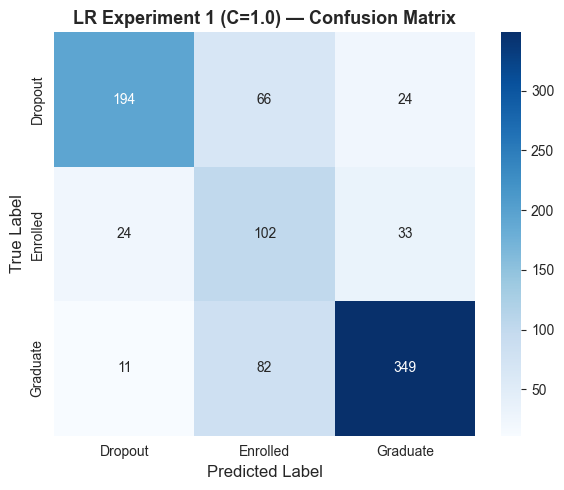

In [12]:
from sklearn.linear_model import LogisticRegression

# Note: multi_class parameter was removed in sklearn 1.7;
# solver='lbfgs' defaults to multinomial for multi-class problems.
lr_exp1 = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE
)
lr_exp1.fit(X_train_scaled, y_train)
y_pred_lr1 = lr_exp1.predict(X_test_scaled)

metrics_lr1 = compute_metrics(y_test, y_pred_lr1)
print_metrics(metrics_lr1, "Logistic Regression — Exp 1 (C=1.0)")
plot_confusion_matrix(
    metrics_lr1['confusion_matrix'],
    title="LR Experiment 1 (C=1.0) — Confusion Matrix"
)

#### 4.3.1 Experiment 1 Interpretation

The baseline achieved 72.88% accuracy and a weighted F1 of 0.7434. Graduate F1 came in at 0.8231, which is strong, and Dropout F1 at 0.7563 is reasonable. The problem is Enrolled, which sits at 0.4988 with a precision of only 0.4080. The model is catching 64% of actual Enrolled students but is also misclassifying many non-Enrolled students into that class, which drags precision down. This is the expected behaviour for a linear model on an imbalanced dataset with correlated features. It struggles to draw a clean boundary around the minority class.

#### 4.3.2 Experiment 2 — Stronger Regularisation (C=0.1)

C=0.1 applies a stronger L2 penalty than the baseline, shrinking coefficients more aggressively toward zero. The motivation comes directly from Experiment 1: if the baseline showed signs of instability or poor Enrolled recall, stronger regularisation should help by reducing the influence of correlated semester features on individual coefficients. If performance improves, it confirms that multicollinearity was hurting the baseline model.


  Logistic Regression — Exp 2 (C=0.1)
  Accuracy     : 0.7288
  Weighted F1  : 0.7446
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.8522   0.6901   0.7626      284
  Enrolled         0.4039   0.6478   0.4976      159
  Graduate         0.8650   0.7828   0.8219      442



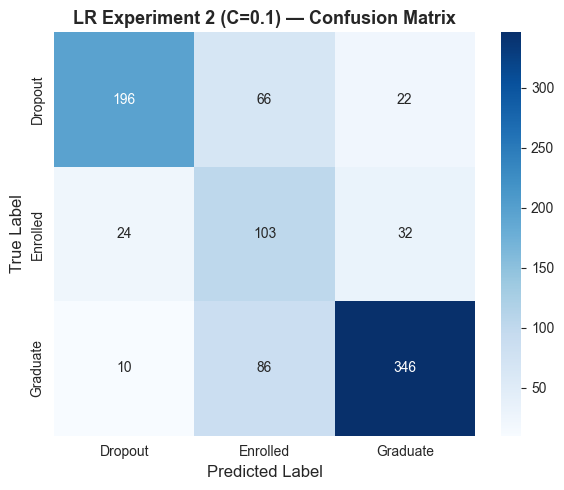

In [13]:
lr_exp2 = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    max_iter=1000,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE
)
lr_exp2.fit(X_train_scaled, y_train)
y_pred_lr2 = lr_exp2.predict(X_test_scaled)

metrics_lr2 = compute_metrics(y_test, y_pred_lr2)
print_metrics(metrics_lr2, "Logistic Regression — Exp 2 (C=0.1)")
plot_confusion_matrix(
    metrics_lr2['confusion_matrix'],
    title="LR Experiment 2 (C=0.1) — Confusion Matrix"
)

#### 4.3.2 Experiment 2 Interpretation

Stronger regularisation (C=0.1) produced marginal improvement: weighted F1 moved from 0.7434 to 0.7446. The change is small enough to be negligible in practice. Enrolled recall stayed at 0.6478 and precision barely shifted. This result confirms what the EDA suggested: the multicollinearity among semester features is not the primary limiting factor for Logistic Regression on this dataset. The model's ceiling is the linear decision boundary itself. No amount of regularisation can capture the non-linear interactions between features that are driving student outcomes.

#### 4.3.3 Experiment 3 — Relaxed Regularisation (C=10.0)

C=10.0 applies a much weaker L2 penalty, giving the model more freedom to fit the training data. This tests whether the model was being over-constrained in previous experiments, or whether additional flexibility leads to overfitting given the multicollinear features. The comparison between C=0.1, C=1.0, and C=10.0 reveals how sensitive Logistic Regression is to regularisation strength on this specific dataset.


  Logistic Regression — Exp 3 (C=10.0)
  Accuracy     : 0.7299
  Weighted F1  : 0.7443
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.8472   0.6831   0.7563      284
  Enrolled         0.4096   0.6415   0.5000      159
  Graduate         0.8600   0.7919   0.8245      442



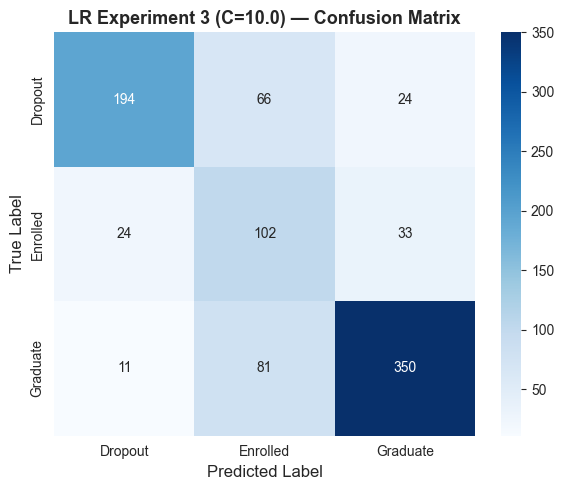

In [14]:
lr_exp3 = LogisticRegression(
    C=10.0,
    solver='lbfgs',
    max_iter=1000,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE
)
lr_exp3.fit(X_train_scaled, y_train)
y_pred_lr3 = lr_exp3.predict(X_test_scaled)

metrics_lr3 = compute_metrics(y_test, y_pred_lr3)
print_metrics(metrics_lr3, "Logistic Regression — Exp 3 (C=10.0)")
plot_confusion_matrix(
    metrics_lr3['confusion_matrix'],
    title="LR Experiment 3 (C=10.0) — Confusion Matrix"
)

#### 4.3.3 Experiment 3 Interpretation

Relaxing regularisation to C=10.0 produced almost identical results to the baseline: weighted F1 of 0.7443, Enrolled F1 of 0.5000. Across all three experiments, the weighted F1 range is only 0.0012. This near-total insensitivity to regularisation strength is itself informative. It means Logistic Regression has reached its performance ceiling on this data regardless of the penalty applied. The best configuration is C=0.1 by a marginal amount, but the practical difference is negligible. The model's limitation is architectural, not a tuning problem.

### 4.3.4 Logistic Regression Summary

The best Logistic Regression configuration is C=0.1 with a weighted F1 of 0.7446. However, the spread across all three experiments is only 0.0012, which means regularisation strength has almost no impact on this model's performance. The real pattern across all three runs is consistent: Graduate and Dropout are predicted reasonably well, but Enrolled precision stays stuck around 0.40 regardless of C value. This points to a structural limitation. The four strongest features identified in the EDA are all semester performance metrics, which are also heavily correlated with each other. A linear model cannot disentangle those correlations into a reliable minority class boundary. This directly motivates the use of Random Forest as the second model.

### 4.4 Random Forest

Random Forest builds an ensemble of decision trees, each trained on a bootstrap sample of the training data with a random subset of features considered at each split (Breiman, 2001). This random feature subsampling directly addresses the multicollinearity problem. No single tree sees all of the correlated semester features simultaneously, so the ensemble is not dominated by that feature cluster. Predictions are made by majority vote across all trees.

Experiment 1 uses a conservative baseline with 100 trees and max_depth=10, to establish what the model can do without being too deep or too shallow. The depth limit is chosen deliberately to prevent individual trees from memorising training samples, which is a known risk with deep unconstrained trees on datasets of this size. Experiments 2 and 3 then adjust depth and tree count based on what the baseline reveals about underfitting or overfitting.

Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5-32.

#### 4.4.1 Experiment 1 — Conservative Baseline (n_estimators=100, max_depth=10)

This baseline tests whether a moderately sized forest with controlled depth can capture the non-linear interactions between semester features that Logistic Regression cannot. max_depth=10 limits tree complexity to reduce overfitting while still allowing the trees to model feature interactions beyond what a linear boundary could represent.


  Random Forest — Exp 1 (n=100, depth=10)
  Accuracy     : 0.7514
  Weighted F1  : 0.7558
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.8312   0.6937   0.7562      284
  Enrolled         0.4588   0.5597   0.5042      159
  Graduate         0.8348   0.8575   0.8460      442



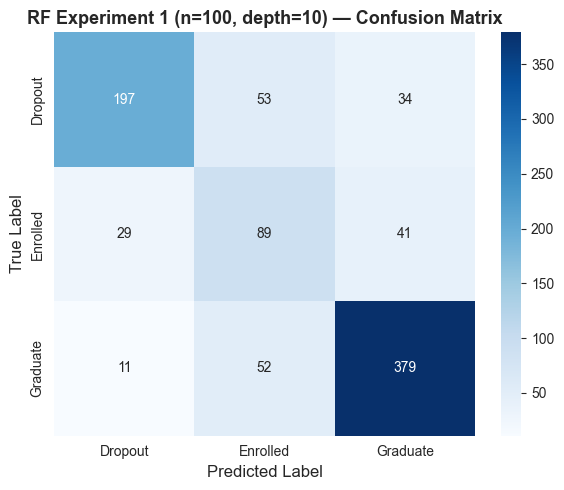

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_exp1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_exp1.fit(X_train_scaled, y_train)
y_pred_rf1 = rf_exp1.predict(X_test_scaled)

metrics_rf1 = compute_metrics(y_test, y_pred_rf1)
print_metrics(metrics_rf1, "Random Forest — Exp 1 (n=100, depth=10)")
plot_confusion_matrix(
    metrics_rf1['confusion_matrix'],
    title="RF Experiment 1 (n=100, depth=10) — Confusion Matrix"
)

#### 4.4.1 Experiment 1 Interpretation

The conservative baseline outperformed every Logistic Regression experiment: accuracy 75.14%, weighted F1 0.7558. More importantly, Enrolled F1 improved to 0.5042 compared to around 0.499 for the best LR run. The gain is modest but meaningful because it comes alongside better Graduate F1 (0.8460 vs 0.8231) and similar Dropout F1 (0.7562). Random Forest is already capturing non-linear feature interactions that the linear model could not access, exactly as predicted by the EDA findings. The question now is whether allowing deeper trees improves things further or introduces overfitting.

#### 4.4.2 Experiment 2 — Deeper Trees (n_estimators=100, max_depth=20)

This experiment increases max_depth from 10 to 20, allowing trees to model more complex decision boundaries. The motivation comes from Experiment 1: if the baseline showed signs of underfitting or poor minority class recall, deeper trees should capture more of the feature interactions. If performance drops instead, it indicates the deeper trees are overfitting to training noise.


  Random Forest — Exp 2 (n=100, depth=20)
  Accuracy     : 0.7706
  Weighted F1  : 0.7582
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.8154   0.7465   0.7794      284
  Enrolled         0.5455   0.3774   0.4461      159
  Graduate         0.7961   0.9276   0.8568      442



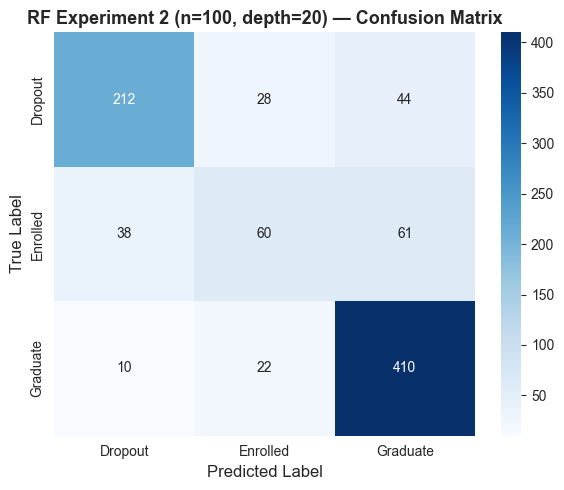

In [16]:
rf_exp2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_exp2.fit(X_train_scaled, y_train)
y_pred_rf2 = rf_exp2.predict(X_test_scaled)

metrics_rf2 = compute_metrics(y_test, y_pred_rf2)
print_metrics(metrics_rf2, "Random Forest — Exp 2 (n=100, depth=20)")
plot_confusion_matrix(
    metrics_rf2['confusion_matrix'],
    title="RF Experiment 2 (n=100, depth=20) — Confusion Matrix"
)

#### 4.4.2 Experiment 2 Interpretation

Increasing max_depth from 10 to 20 raised the weighted F1 to 0.7582, the highest of all six experiments so far. Accuracy also climbed to 77.06% and Graduate F1 reached 0.8568. However, Enrolled F1 dropped sharply from 0.5042 to 0.4461. This is a clear bias-variance trade-off. Deeper trees model the majority classes more precisely but at the cost of the minority class. For a student dropout prediction system, this is a meaningful concern. A model that improves at identifying graduates while getting worse at identifying at-risk Enrolled students is less useful in practice, even if its aggregate metric looks better.

#### 4.4.3 Experiment 3 — More Trees, Unconstrained Depth (n_estimators=200, max_depth=None)

This experiment removes the depth constraint entirely and increases the number of trees to 200. Unconstrained trees will grow until all leaves are pure, which maximises individual tree expressiveness but risks overfitting. Increasing n_estimators to 200 partially offsets this risk by increasing ensemble diversity, since more trees produce more variance reduction through averaging (Breiman, 2001).

Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5-32.


  Random Forest — Exp 3 (n=200, depth=None)
  Accuracy     : 0.7684
  Weighted F1  : 0.7544
-------------------------------------------------------
  Class         Precision   Recall       F1  Support
-------------------------------------------------------
  Dropout          0.8185   0.7465   0.7808      284
  Enrolled         0.5686   0.3648   0.4444      159
  Graduate         0.7824   0.9276   0.8489      442



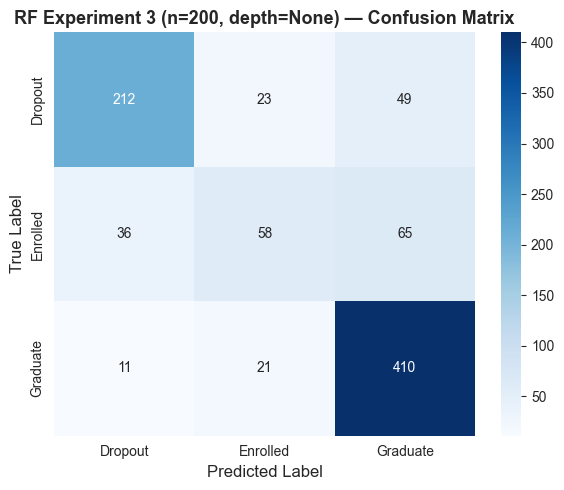

In [17]:
rf_exp3 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_exp3.fit(X_train_scaled, y_train)
y_pred_rf3 = rf_exp3.predict(X_test_scaled)

metrics_rf3 = compute_metrics(y_test, y_pred_rf3)
print_metrics(metrics_rf3, "Random Forest — Exp 3 (n=200, depth=None)")
plot_confusion_matrix(
    metrics_rf3['confusion_matrix'],
    title="RF Experiment 3 (n=200, depth=None) — Confusion Matrix"
)

#### 4.4.3 Experiment 3 Interpretation

Removing the depth constraint entirely and increasing trees to 200 produced results almost identical to Experiment 2: weighted F1 0.7544, Enrolled F1 0.4444. The additional trees did not recover the minority class performance lost by removing the depth limit. Unconstrained trees grow until all leaves are pure, which means they are fitting individual training samples rather than generalising patterns. The ensemble averaging partially offsets this, but the Enrolled class still suffers. This confirms that depth is the critical hyperparameter for this dataset, not the number of trees.

### 4.4.4 Random Forest Summary

The best Random Forest configuration depends on what is being optimised. RF Exp 2 (n=100, max_depth=20) achieves the highest weighted F1 at 0.7582, making it the strongest model by aggregate metric. However, RF Exp 1 (n=100, max_depth=10) achieves the best Enrolled F1 at 0.5042, which is the most practically important class for a student dropout prediction system. The depth=20 model trades minority class performance for majority class accuracy, which is a questionable trade-off in this context. Both configurations are carried forward to the comparison table. The chosen best model for comparison against the neural network is RF Exp 1 (depth=10) on the grounds that Enrolled recall is the more meaningful metric for the real-world problem this study addresses.

### 4.5 Classical Models Summary

The table below consolidates results from all six experiments across both models. Weighted F1 is the ranking metric, but per-class F1 for Enrolled is included separately because it is the hardest class and the most meaningful indicator of real-world utility.

In [18]:
results = []
experiments = [
    ("LR C=1.0",        metrics_lr1),
    ("LR C=0.1",        metrics_lr2),
    ("LR C=10.0",       metrics_lr3),
    ("RF n=100 d=10",   metrics_rf1),
    ("RF n=100 d=20",   metrics_rf2),
    ("RF n=200 d=None", metrics_rf3),
]

for name, m in experiments:
    results.append({
        'Model'       : name,
        'Accuracy'    : m['accuracy'],
        'Weighted F1' : m['weighted_f1'],
        'Dropout F1'  : m['Dropout']['F1'],
        'Enrolled F1' : m['Enrolled']['F1'],
        'Graduate F1' : m['Graduate']['F1'],
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    'Weighted F1', ascending=False
).reset_index(drop=True)

print("Classical Models — All Experiments Summary")
print(results_df.to_string(index=False))

Classical Models — All Experiments Summary
          Model  Accuracy  Weighted F1  Dropout F1  Enrolled F1  Graduate F1
  RF n=100 d=20    0.7706       0.7582      0.7794       0.4461       0.8568
  RF n=100 d=10    0.7514       0.7558      0.7562       0.5042       0.8460
RF n=200 d=None    0.7684       0.7544      0.7808       0.4444       0.8489
       LR C=0.1    0.7288       0.7446      0.7626       0.4976       0.8219
      LR C=10.0    0.7299       0.7443      0.7563       0.5000       0.8245
       LR C=1.0    0.7288       0.7434      0.7563       0.4988       0.8231


### 4.6 Classical Models Discussion

Random Forest outperformed Logistic Regression on every metric across every experiment, which is exactly what the EDA predicted. The top correlated features are highly intercorrelated semester performance variables. A linear model cannot separate those interactions into distinct class boundaries, and the near-flat regularisation sensitivity confirmed this. Random Forest sidesteps the multicollinearity problem entirely through random feature subsampling, and its ensemble structure captures the non-linear interactions between semester one and semester two performance that drive student outcomes.

The Enrolled class was the hardest to predict in every single experiment. The best Enrolled F1 achieved was 0.5042 by RF Exp 1. This is not surprising. Enrolled students are by definition mid-journey: they have not yet dropped out, but they have not graduated either. Their feature profiles likely overlap with both other classes, making the decision boundary inherently ambiguous.

The regularisation experiments on Logistic Regression produced a 0.0012 range in weighted F1 across C values of 0.1, 1.0, and 10.0. This near-total insensitivity is a direct consequence of the multicollinearity: when features carry redundant information, adjusting the penalty on their coefficients produces little practical effect on the output probabilities.

These results set a clear benchmark for the neural network. It must beat a weighted F1 of 0.7582 to demonstrate that the added complexity of a from-scratch implementation is justified. More importantly, it should improve Enrolled F1 beyond 0.5042, since that is where both classical models fell short and where the real-world value of the system lies.